<a href="https://colab.research.google.com/github/MalekiMostafa/DeepLearning1403/blob/Project/Project3_TextClassifierWithAttention/DL_Project3_Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Attention-Based Model for Text Classification

## Introduction
This project implements an attention-based model for text classification, aiming to identify key parts of input text and improve classification accuracy. The model is applied to categorize consumer complaints based on product types.

## Project Objectives
1. Utilize an attention mechanism for text processing.
2. Improve text classification accuracy for predefined categories.
3. Evaluate the model's performance using real-world consumer complaints data.

## Dataset
The dataset is sourced from `Consumer_Complaints.csv`, which contains consumer complaints about various products. The `Product` column specifies the category for each complaint. The data is preprocessed and converted into numerical features using the GloVe model.

## Data Preprocessing
1. Remove missing values from complaint texts.
2. Standardize product category names using a `product_map` dictionary.
3. Process text:
   - Convert to lowercase.
   - Remove punctuation and numbers.
   - Eliminate extra spaces.
   - Trim each text to 20 words.
4. Transform processed texts into numerical vectors using the GloVe model.

## GloVe Model Selection
The 300-dimensional GloVe model is chosen to prevent underfitting and enable more precise feature extraction, improving classification performance for complex texts.

## Attention Model Design
The model consists of:
1. An attention layer to compute attention weights for each word.
2. Tanh activation function.
3. Softmax layer for normalizing attention weights.
4. A final linear layer for classification predictions.

## Model Training and Evaluation
- The dataset is split into training, validation, and test sets.
- The model is trained using the Adam optimizer and CrossEntropyLoss function.
- Performance is evaluated using accuracy, classification error, and confusion matrix.

## Training Results
- Epoch 7: Validation loss = 0.7253.
- Epoch 8: Validation loss = 0.7253.
- Epoch 9: Validation loss = 0.7211.
- Epoch 10: Validation loss = 0.7211.

## Model Evaluation
- Model Accuracy: 76.54%
- Test Loss: 0.723188221201603

## Prediction on a New Complaint
A new complaint sample was classified as `credit_report`.

## Confusion Matrix Analysis
- High diagonal values indicate correct predictions.
- Misclassifications occur in semantically similar categories like `loan` and `debt_collection`.
- Categories like `savings_account` and `vehicle_loan` show higher accuracy.

## Attention Weight Analysis
Attention weights highlight key words in the input text. For example, in the sentence "I am a victim of identity theft," the model assigns high weights to words like `that` and `account`.

## Conclusion
The attention-based model significantly improves text classification accuracy. Future enhancements could include:
1. Implementing advanced models like BERT.
2. Expanding the training dataset.
3. Optimizing attention weight configurations.

This project demonstrates the potential of attention mechanisms in NLP tasks and serves as a foundation for further research.

##Conclusion

This project demonstrates the effectiveness of using an attention mechanism for text classification tasks. By focusing on relevant parts of the input text, the attention model achieves improved accuracy in categorizing consumer complaints into predefined product categories.

In [ ]:
import re
import torch
import pickle
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch.nn as nn
from nltk.tokenize import word_tokenize
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
lr = 0.0005
vec_len = 300
seq_len = 20
num_epochs = 10
label_col = "Product"
tokens_path = "/content/drive/MyDrive/DL_Project3_Attention/tokens.pkl"
labels_path = "/content/drive/MyDrive/DL_Project3_Attention/labels.pkl"
data_path = "/content/drive/MyDrive/DL_Project3_Attention/Consumer_Complaints.csv"
model_path = "/content/drive/MyDrive/DL_Project3_Attention/attention.pth"
vocabulary_path = "/content/drive/MyDrive/DL_Project3_Attention/vocabulary.pkl"
embeddings_path = "/content/drive/MyDrive/DL_Project3_Attention/embeddings.pkl"
text_col_name = "Consumer Complaint"
label_encoder_path = "/content/drive/MyDrive/DL_Project3_Attention/label_encoder.pkl"
product_map = {'Vehicle loan or lease': 'vehicle_loan',
               'Credit reporting, credit repair services, or other personal consumer reports': 'credit_report',
               'Credit card or prepaid card': 'card',
               'Money transfer, virtual currency, or money service': 'money_transfer',
               'virtual currency': 'money_transfer',
               'Mortgage': 'mortgage',
               'Payday loan, title loan, or personal loan': 'loan',
               'Debt collection': 'debt_collection',
               'Checking or savings account': 'savings_account',
               'Credit card': 'card',
               'Bank account or service': 'savings_account',
               'Credit reporting': 'credit_report',
               'Prepaid card': 'card',
               'Payday loan': 'loan',
               'Other financial service': 'others',
               'Virtual currency': 'money_transfer',
               'Student loan': 'loan',
               'Consumer Loan': 'loan',
               'Money transfers': 'money_transfer'}

Process text data

In [ ]:
data = pd.read_csv(data_path)

print(data.head())

  Date received           Product     Sub-product  \
0    03-12-2014          Mortgage  Other mortgage   
1    10-01-2016  Credit reporting             NaN   
2    10/17/2016     Consumer Loan    Vehicle loan   
3    06-08-2014       Credit card             NaN   
4    09/13/2014   Debt collection     Credit card   

                                      Issue                   Sub-issue  \
0  Loan modification,collection,foreclosure                         NaN   
1    Incorrect information on credit report              Account status   
2                Managing the loan or lease                         NaN   
3                                Bankruptcy                         NaN   
4                     Communication tactics  Frequent or repeated calls   

                                  Consumer Complaint  \
0                                                NaN   
1  I have outdated information on my credit repor...   
2  I purchased a new car on XXXX XXXX. The car de...   
3     

In [ ]:
data.dropna(subset=[text_col_name], inplace=True)

data.replace({label_col: product_map}, inplace=True)

In [ ]:
import os
import requests

# URL فایل GloVe
glove_url = "https://nlp.stanford.edu/data/glove.42B.300d.zip"

# مسیر ذخیره فایل دانلود شده
glove_zip_path = "/content/drive/MyDrive/DL_Project3_Attention/glove.42B.300d.zip"

# دانلود فایل
if not os.path.exists(glove_zip_path):
    print("در حال دانلود فایل GloVe...")
    response = requests.get(glove_url, stream=True)
    with open(glove_zip_path, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024):
            if chunk:
                f.write(chunk)
    print("دانلود کامل شد!")
else:
    print("فایل از قبل دانلود شده است.")

# اکسترکت فایل ZIP
import zipfile

glove_extract_path = "/content/glove.42B.300d"
if not os.path.exists(glove_extract_path):
    print("در حال اکسترکت فایل...")
    with zipfile.ZipFile(glove_zip_path, 'r') as zip_ref:
        zip_ref.extractall(glove_extract_path)
    print("اکسترکت کامل شد!")
else:
    print("فایل از قبل اکسترکت شده است.")

# مسیر فایل glove.42B.300d.txt با استفاده از glove_vector_path
glove_vector_path = os.path.join(glove_extract_path, "glove.42B.300d.txt")

# بررسی وجود فایل
if os.path.exists(glove_vector_path):
    print(f"فایل GloVe در مسیر زیر ذخیره شده است: {glove_vector_path}")
else:
    print("فایل GloVe یافت نشد!")

فایل از قبل دانلود شده است.
فایل از قبل اکسترکت شده است.
فایل GloVe در مسیر زیر ذخیره شده است: /content/glove.42B.300d/glove.42B.300d.txt


In [ ]:
def save_file(name, obj):
    """
    Function to save an object as pickle file
    """
    with open(name, 'wb') as f:
        pickle.dump(obj, f)


def load_file(name):
    """
    Function to load a pickle object
    """
    return pickle.load(open(name, "rb"))

Process glove embeddings

In [ ]:
with open(glove_vector_path, "rt", encoding="utf-8") as f:
    emb = f.readlines()


In [ ]:
vocabulary, embeddings = [], []

for item in emb:
    vocabulary.append(item.split()[0])
    embeddings.append(item.split()[1:])

In [ ]:
embeddings = np.array(embeddings, dtype=np.float32)

In [ ]:
vocabulary = ["<pad>", "<unk>"] + vocabulary

In [ ]:
import numpy as np

ones_array = np.ones((1, 300), dtype=np.float32)


embeddings = np.vstack([ones_array,
                        np.mean(embeddings, axis=0).reshape(1, -1),
                        embeddings])

In [ ]:
save_file(embeddings_path, embeddings)
save_file(vocabulary_path, vocabulary)

Encode labels

In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(data[label_col])
labels = label_encoder.transform(data[label_col])

save_file(labels_path, labels)
save_file(label_encoder_path, label_encoder)


Process the text column

In [ ]:
input_text = list(data[text_col_name])

len(input_text)

277814

Convert text to lower case

Remove punctuations except apostrophe

In [ ]:
input_text = [i.lower() for i in tqdm(input_text)]

100%|██████████| 277814/277814 [00:00<00:00, 908720.13it/s]


In [ ]:
input_text = [re.sub(r"[^\w\d'\s]+", " ", i)
              for i in tqdm(input_text)]

100%|██████████| 277814/277814 [00:08<00:00, 31600.36it/s]


Remove digits

In [ ]:
input_text = [re.sub("\d+", "", i) for i in tqdm(input_text)]

100%|██████████| 277814/277814 [00:05<00:00, 50335.05it/s]


Remove more than one consecutive instance of 'x'

In [ ]:
input_text = [re.sub(r'[x]{2,}', "", i) for i in tqdm(input_text)]

100%|██████████| 277814/277814 [00:04<00:00, 59411.32it/s]


Remove multiple spaces with single space

In [ ]:
input_text = [re.sub(' +', ' ', i) for i in tqdm(input_text)]

100%|██████████| 277814/277814 [00:13<00:00, 21125.34it/s]


Tokenize the text

In [ ]:
import nltk
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
tokens = [word_tokenize(t) for t in tqdm(input_text)]

100%|██████████| 277814/277814 [02:03<00:00, 2257.05it/s]


Take the first 20 tokens in each complaint text

In [ ]:
tokens = [i[:20] if len(i) > 19 else ['<pad>'] * (20 - len(i)) + i
          for i in tqdm(tokens)]

100%|██████████| 277814/277814 [00:03<00:00, 77994.45it/s]


Convert tokens to integer indices from vocabulary

In [ ]:
def token_index(tokens, vocabulary, missing='<unk>'):
    """
    :param tokens: List of word tokens
    :param vocabulary: All words in the embeddings
    :param missing: Token for words not present in the vocabulary
    :return: List of integers representing the word tokens
    """
    idx_token = []
    for text in tqdm(tokens):
        idx_text = []
        for token in text:
            if token in vocabulary:
                idx_text.append(vocabulary.index(token))
            else:
                idx_text.append(vocabulary.index(missing))
        idx_token.append(idx_text)
    return idx_token

In [ ]:
tokens = token_index(tokens, vocabulary)

100%|██████████| 277814/277814 [1:37:55<00:00, 47.28it/s]


Save the tokens

In [ ]:
save_file(tokens_path, tokens)

Create attention model

In [ ]:
import torch
import torch.nn as nn
import numpy as np

class AttentionModel(nn.Module):
    def __init__(self, vec_len, seq_len, n_classes):
        super(AttentionModel, self).__init__()
        self.vec_len = vec_len
        self.seq_len = seq_len

        # Attention weights for calculating the full matrix
        self.attn_weights = nn.Parameter(torch.randn(vec_len+1 , vec_len+1 ) / torch.sqrt(torch.tensor(vec_len+1 )))

        self.activation = nn.Tanh()
        self.softmax = nn.Softmax(dim=-1)
        self.linear = nn.Linear(vec_len + 1, n_classes)
        self.attention_scores = None  # To store attention values

    def forward(self, input_data, return_attention=False):
        # Calculate the full attention matrix
        hidden = torch.matmul(input_data, self.attn_weights)  # (batch_size, seq_len, vec_len + 1) * (vec_len + 1, vec_len + 1)
        hidden = self.activation(hidden)

        # Full attention matrix
        attn = torch.matmul(hidden, input_data.transpose(1, 2))  # (batch_size, seq_len, seq_len)
        attn = self.softmax(attn)

        # Store attention values
        self.attention_scores = attn.detach().clone()

        # Apply attention to input
        attn_output = torch.matmul(attn, input_data)  # (batch_size, seq_len, vec_len + 1)
        output = self.linear(attn_output.mean(dim=1))  # Mean across tokens

        if return_attention:
            return output, self.attention_scores
        return output

    def get_attention_weights(self):
        """
        Return attention weights
        Returns:
            - attention_weights: the learned attention parameters
            - attention_scores: attention values for the last input
        """
        return {
            'attention_weights': self.attn_weights.detach().cpu(),
            'attention_scores': self.attention_scores.cpu() if self.attention_scores is not None else None
        }


Create PyTorch dataset

In [ ]:
class TextDataset(torch.utils.data.Dataset):

    def __init__(self, tokens, embeddings, labels):
        """
        :param tokens: List of word tokens
        :param embeddings: Word embeddings (from glove)
        :param labels: List of labels
        """
        self.tokens = tokens
        self.embeddings = embeddings
        self.labels = labels

    def __len__(self):
        return len(self.tokens)

    def __getitem__(self, idx):
        emb = torch.tensor(self.embeddings[self.tokens[idx], :])
        input_ = torch.cat((torch.ones(emb.shape[0],1), emb), dim=1)
        return torch.tensor(self.labels[idx]), input_


Function to train the model

In [ ]:
def train(train_loader, valid_loader, model, criterion, optimizer,
          device, num_epochs, model_path):
    """
    Function to train the model
    :param train_loader: Data loader for train dataset
    :param valid_loader: Data loader for validation dataset
    :param model: Model object
    :param criterion: Loss function
    :param optimizer: Optimizer
    :param device: CUDA or CPU
    :param num_epochs: Number of epochs
    :param model_path: Path to save the model
    """
    best_loss = 1e8
    for i in range(num_epochs):
        print(f"Epoch {i+1} of {num_epochs}")
        valid_loss, train_loss = [], []
        model.train()
        # Train loop
        for batch_labels, batch_data in tqdm(train_loader):
            # Move data to GPU if available
            batch_labels = batch_labels.to(device)
            batch_data = batch_data.to(device)
            # Forward pass
            batch_output = model(batch_data)
            batch_output = torch.squeeze(batch_output)
            # Calculate loss
            loss = criterion(batch_output, batch_labels)
            train_loss.append(loss.item())
            optimizer.zero_grad()
            # Backward pass
            loss.backward()
            # Gradient update step
            optimizer.step()
        model.eval()
        # Validation loop
        for batch_labels, batch_data in tqdm(valid_loader):
            # Move data to GPU if available
            batch_labels = batch_labels.to(device)
            batch_data = batch_data.to(device)
            # Forward pass
            batch_output = model(batch_data)
            batch_output = torch.squeeze(batch_output)
            # Calculate loss
            loss = criterion(batch_output, batch_labels)
            valid_loss.append(loss.item())
        t_loss = np.mean(train_loss)
        v_loss = np.mean(valid_loss)
        print(f"Train Loss: {t_loss}, Validation Loss: {v_loss}")
        if v_loss < best_loss:
            best_loss = v_loss
            # Save model if validation loss improves
            torch.save(model.state_dict(), model_path)
        print(f"Best Validation Loss: {best_loss}")

Function to test the model

In [ ]:
def test(test_loader, model, criterion, device):
    """
    Function to test the model
    :param test_loader: Data loader for test dataset
    :param model: Model object
    :param criterion: Loss function
    :param device: CUDA or CPU
    """
    model.eval()
    test_loss = []
    test_accu = []
    for batch_labels, batch_data in tqdm(test_loader):
        # Move data to device
        batch_labels = batch_labels.to(device)
        batch_data = batch_data.to(device)
        # Forward pass
        batch_output = model(batch_data)
        batch_output = torch.squeeze(batch_output)
        # Calculate loss
        loss = criterion(batch_output, batch_labels)
        test_loss.append(loss.item())
        batch_preds = torch.argmax(batch_output, axis=1)
        # Move predictions to CPU
        if torch.cuda.is_available():
            batch_labels = batch_labels.cpu()
            batch_preds = batch_preds.cpu()
        # Compute accuracy
        test_accu.append(accuracy_score(batch_labels.detach().
                                        numpy(),
                                        batch_preds.detach().
                                        numpy()))
    test_loss = np.mean(test_loss)
    test_accu = np.mean(test_accu)
    print(f"Test Loss: {test_loss}, Test Accuracy: {test_accu}")

###Train attention model

Load the files

In [ ]:
tokens = load_file(tokens_path)
labels = load_file(labels_path)
embeddings = load_file(embeddings_path)
label_encoder = load_file(label_encoder_path)
num_classes = len(label_encoder.classes_)
vocabulary = load_file(vocabulary_path)

Split data into train, validation and test sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(tokens, labels,
                                                    test_size=0.2)
X_train, X_valid, y_train, y_valid = train_test_split(X_train,
                                                      y_train,
                                                      test_size=0.25)

Create PyTorch datasets

In [ ]:
train_dataset = TextDataset(X_train, embeddings, y_train)
valid_dataset = TextDataset(X_valid, embeddings, y_valid)
test_dataset = TextDataset(X_test, embeddings, y_test)

Create data loaders

In [ ]:
train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=16,
                                           shuffle=True,
                                           drop_last=True)
valid_loader = torch.utils.data.DataLoader(valid_dataset,
                                           batch_size=16)
test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size=16)


Create model object

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available()
                      else "cpu")

In [ ]:
model = AttentionModel(vec_len, seq_len, num_classes)


Move the model to GPU if available

In [ ]:
if torch.cuda.is_available():
    model = model.cuda()

Define loss function and optimizer

In [ ]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

Training loop

In [ ]:
train(train_loader, valid_loader, model, criterion, optimizer,
      device, 10, model_path)

Epoch 1 of 10


100%|██████████| 3473/3473 [00:19<00:00, 175.40it/s]


Train Loss: 0.8448121327721619, Validation Loss: 0.7776341388222466
Best Validation Loss: 0.7776341388222466
Epoch 2 of 10


100%|██████████| 3473/3473 [00:20<00:00, 167.64it/s]


Train Loss: 0.7427284356451956, Validation Loss: 0.7505710122845649
Best Validation Loss: 0.7505710122845649
Epoch 3 of 10


...

Train Loss: 0.6512017034553457, Validation Loss: 0.7266464398092095
Best Validation Loss: 0.7253060307865385
Epoch 9 of 10


100%|██████████| 3473/3473 [00:22<00:00, 155.53it/s]


Train Loss: 0.6434098455520698, Validation Loss: 0.7211862931480127
Best Validation Loss: 0.7211862931480127
Epoch 10 of 10


100%|██████████| 3473/3473 [00:17<00:00, 203.05it/s]

Train Loss: 0.637094753699434, Validation Loss: 0.7244146453083128
Best Validation Loss: 0.7211862931480127


Test the model

In [ ]:
test(test_loader, model, criterion, device)

100%|██████████| 3473/3473 [00:25<00:00, 135.35it/s]

Test Loss: 0.723188271201673, Test Accuracy: 0.7654421773159177


Predict on new text

In [ ]:
input_text = '''I am a victim of Identity Theft & currently have an Experian account that
I can view my Experian Credit Report and getting notified when there is activity on
my Experian Credit Report. For the past 3 days I've spent a total of approximately 9
hours on the phone with Experian. Every time I call I get transferred repeatedly and
then my last transfer and automated message states to press 1 and leave a message and
someone would call me. Every time I press 1 I get an automatic message stating than you
before I even leave a message and get disconnected. I call Experian again, explain what
is happening and the process begins again with the same end result. I was trying to have
this issue attended and resolved informally but I give up after 9 hours. There are hard
hit inquiries on my Experian Credit Report that are fraud, I didn't authorize, or recall
and I respectfully request that Experian remove the hard hit inquiries immediately just
like they've done in the past when I was able to speak to a live Experian representative
in the United States. The following are the hard hit inquiries : BK OF XXXX XX/XX/XXXX
XXXX XXXX XXXX  XX/XX/XXXX XXXX  XXXX XXXX  XX/XX/XXXX XXXX  XX/XX/XXXX XXXX  XXXX
XX/XX/XXXX'''

Process input text

In [ ]:
input_text = input_text.lower()
input_text = re.sub(r"[^\w\d'\s]+", " ", input_text)
input_text = re.sub("\d+", "", input_text)
input_text = re.sub(r'[x]{2,}', "", input_text)
input_text = re.sub(' +', ' ', input_text)
tokens = word_tokenize(input_text)

In [ ]:
tokens = ['<pad>']*(20-len(tokens))+tokens

In [ ]:
idx_token = []
for token in tokens:
    if token in vocabulary:
        idx_token.append(vocabulary.index(token))
    else:
        idx_token.append(vocabulary.index('<unk>'))

In [ ]:
token_emb = embeddings[idx_token,:]
token_emb = token_emb[:seq_len, :]
inp = torch.from_numpy(token_emb)

In [ ]:
inp = torch.cat((torch.ones(inp.shape[0],1), inp), dim=1)

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available()
                      else "cpu")

In [ ]:
inp = inp.to(device)
inp = torch.unsqueeze(inp, 0)

In [ ]:
label_encoder = load_file(label_encoder_path)
num_classes = len(label_encoder.classes_)

In [ ]:
import torch

torch.save(model.state_dict(), model_path)

In [ ]:
# Create model object
model = AttentionModel(vec_len, seq_len, num_classes)

# Load trained weights
model.load_state_dict(torch.load(model_path))

# Move the model to GPU if available
if torch.cuda.is_available():
    model = model.cuda()

# Forward pass
out = torch.squeeze(model(inp))

# Find predicted class
prediction = label_encoder.classes_[torch.argmax(out)]
print(f"Predicted  Class: {prediction}")

Predicted  Class: credit_report


<ipython-input-305-42ae6b6cb67b>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


##Evaluation

In [ ]:
def visualize_complete_attention_weights(model, input_text, vocabulary, embeddings, device, seq_len=20):
    """
    Visualizes complete attention weights matrix for all tokens in the sequence.

    Args:
        model: Trained attention model
        input_text: Input text to analyze
        vocabulary: Vocabulary dictionary
        embeddings: Word embeddings
        device: PyTorch device (cuda/cpu)
        seq_len: Maximum sequence length
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    from nltk.tokenize import word_tokenize
    import torch
    import numpy as np

    # Preprocess input text
    input_text = input_text.lower()
    input_text = re.sub(r"[^\w\d'\s]+", " ", input_text)
    input_text = re.sub("\d+", "", input_text)
    input_text = re.sub(r'[x]{2,}', "", input_text)
    input_text = re.sub(' +', ' ', input_text)
    tokens = word_tokenize(input_text)

    # Pad or truncate tokens
    if len(tokens) < seq_len:
        tokens = ['<pad>'] * (seq_len - len(tokens)) + tokens
    else:
        tokens = tokens[:seq_len]

    # Convert tokens to indices
    idx_token = []
    for token in tokens:
        if token in vocabulary:
            idx_token.append(vocabulary.index(token))
        else:
            idx_token.append(vocabulary.index('<unk>'))

    # Create embeddings tensor
    token_emb = embeddings[idx_token,:]
    token_emb = token_emb[:seq_len, :]
    inp = torch.from_numpy(token_emb).float()
    inp = torch.cat((torch.ones(inp.shape[0], 1), inp), dim=1)

    # Prepare input for model
    inp = inp.to(device)
    inp = torch.unsqueeze(inp, 0)

    # Get model predictions and attention weights
    model.eval()
    with torch.no_grad():
        # Forward pass and get attention scores
        output = model(inp)
        attention_scores = model.attention_scores.squeeze(0).cpu().numpy()

    # Remove padding tokens from visualization if they exist
    non_pad_indices = [i for i, token in enumerate(tokens) if token != '<pad>']
    tokens = [tokens[i] for i in non_pad_indices]
    attention_scores = attention_scores[non_pad_indices]

    # Create heatmap
    plt.figure(figsize=(15, 10))
    sns.heatmap(
        attention_scores,
        cmap='YlOrRd',
        xticklabels=tokens,
        yticklabels=tokens,
        annot=True,
        fmt='.2f',
        square=True
    )

    plt.title("Token-to-Token Attention Weights")
    plt.xlabel("Target Tokens")
    plt.ylabel("Source Tokens")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Print attention summary for each token
    print("\nAttention weight summary for each token:")
    for i, token in enumerate(tokens):
        mean_attention = np.mean(attention_scores[i])
        max_attention = np.max(attention_scores[i])
        print(f"Token: {token:15} | Mean Attention: {mean_attention:.4f} | Max Attention: {max_attention:.4f}")





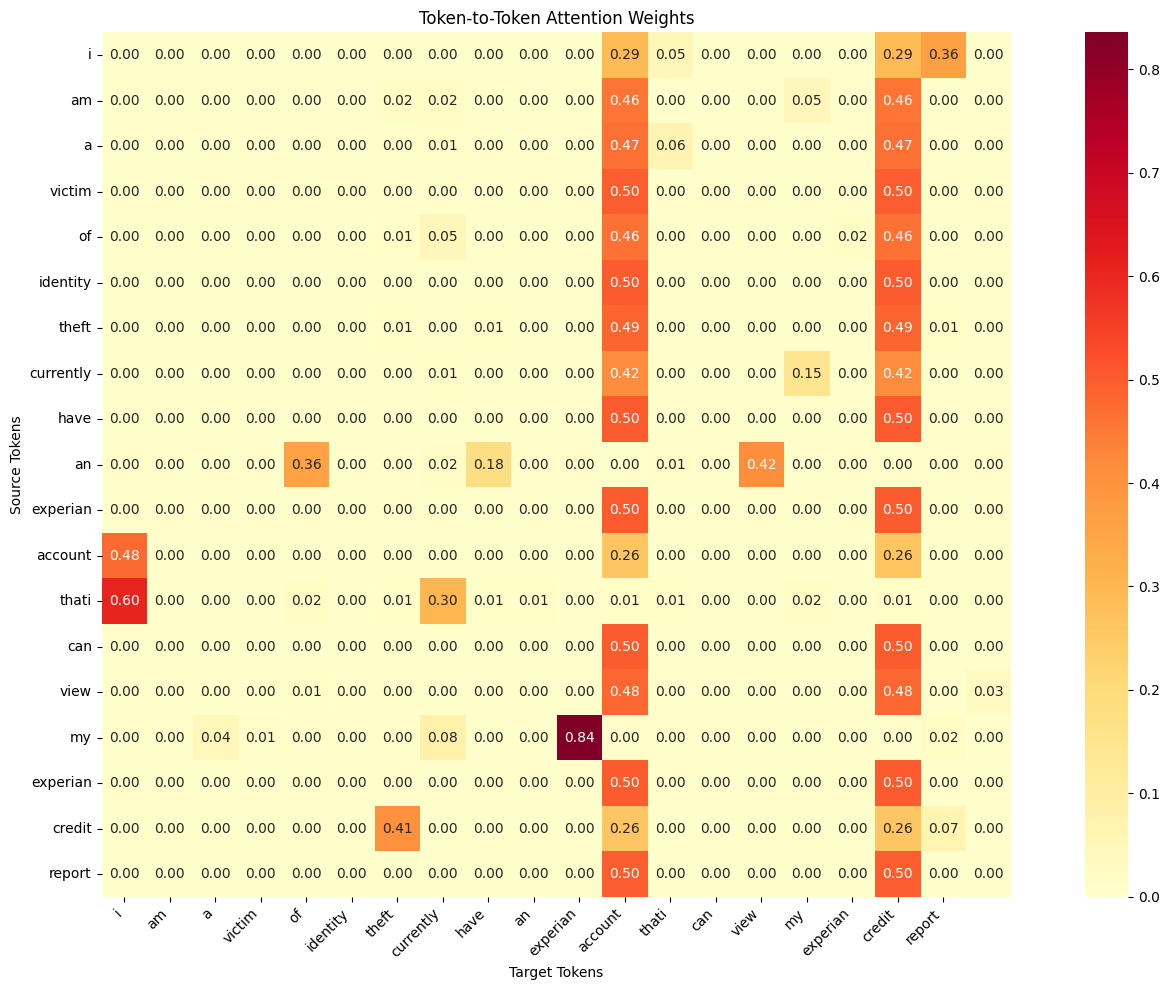


Attention weight summary for each token:
Token: i               | Mean Attention: 0.0500 | Max Attention: 0.3627
Token: am              | Mean Attention: 0.0500 | Max Attention: 0.4572
Token: a               | Mean Attention: 0.0500 | Max Attention: 0.4655
Token: victim          | Mean Attention: 0.0500 | Max Attention: 0.4984
Token: of              | Mean Attention: 0.0500 | Max Attention: 0.4604
Token: identity        | Mean Attention: 0.0500 | Max Attention: 0.5000
Token: theft           | Mean Attention: 0.0500 | Max Attention: 0.4859
Token: currently       | Mean Attention: 0.0500 | Max Attention: 0.4190
Token: have            | Mean Attention: 0.0500 | Max Attention: 0.5000
Token: an              | Mean Attention: 0.0500 | Max Attention: 0.4171
Token: experian        | Mean Attention: 0.0500 | Max Attention: 0.5000
Token: account         | Mean Attention: 0.0500 | Max Attention: 0.4764
Token: thati           | Mean Attention: 0.0500 | Max Attention: 0.6047
Token: can            

In [ ]:
visualize_complete_attention_weights(
    model=model,
    input_text=input_text,
    vocabulary=vocabulary,
    embeddings=embeddings,
    device=device
)

<ipython-input-319-2e54e87295fe>:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


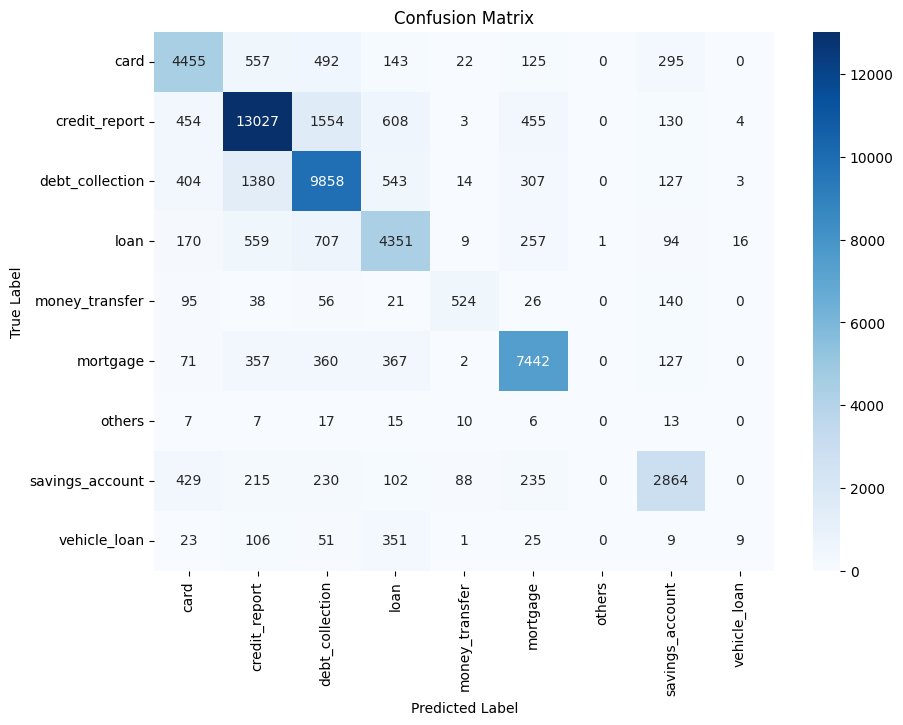

In [ ]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

model = AttentionModel(vec_len, seq_len, num_classes)
model.load_state_dict(torch.load(model_path))
model.to(device)
model.eval()

true_labels = []
pred_labels = []

with torch.no_grad():
    for batch_labels, batch_data in test_loader:
        batch_labels = batch_labels.to(device)
        batch_data = batch_data.to(device)


        outputs = model(batch_data)
        predictions = torch.argmax(outputs, axis=1)


        true_labels.extend(batch_labels.cpu().numpy())
        pred_labels.extend(predictions.cpu().numpy())


cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
